In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy.stats import norm
import matplotlib.pyplot as plt 
import seaborn as sns
import sys

# Load Data

tech_sector_df = pd.read_csv("../data/tech_sector_xlk.csv")
tech_sector_df["returns"] = tech_sector_df["close"].pct_change()
tech_sector_df.dropna(inplace=True)
tech_sector_df["log_returns"] = np.log(1 + tech_sector_df["returns"])


/var/folders/s_/7m7l27gn2bs9lqs5gyg9_hnw0000gn/T/ipykernel_8108/3154000716.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


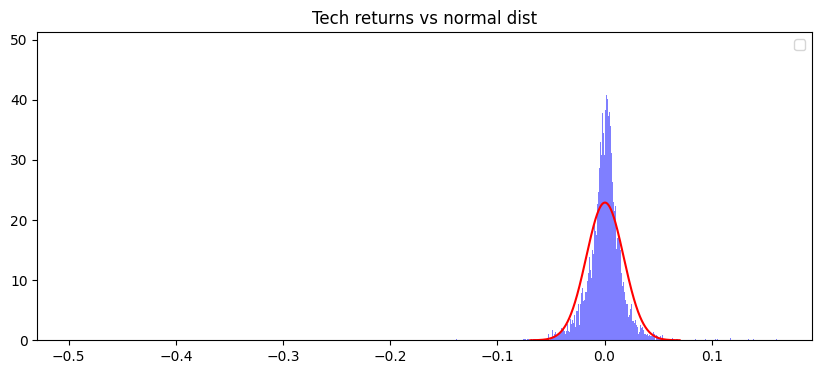

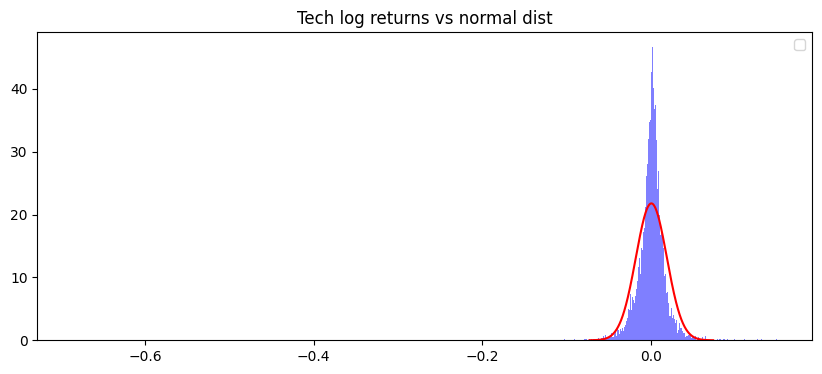

In [2]:
# Visualizing return, log returns and VaR
VaR_x = lambda df_series, percentile: -np.percentile(df_series, 100 - percentile)

def plot_against_normal(returns_series: pd.Series, title: str):
    plt.figure(figsize=(10,4))
    plt.hist(returns_series, bins=1000,
            color='blue', density=True, alpha=0.5)
    mu = returns_series.mean()
    sigma = returns_series.std()
    x = np.linspace(mu-4*sigma, mu+4*sigma, 1000)
    plt.plot(x, norm.pdf(x, mu, sigma),
            color='red',
            )
    plt.title(title)
    plt.legend()
    plt.show()

# with returns 
plot_against_normal(tech_sector_df["returns"], "Tech returns vs normal dist")

# with log returns
plot_against_normal(tech_sector_df["log_returns"], "Tech log returns vs normal dist")


Very inaccurate plots in the middle and near the tails.

skew: -7.659751382310089, kurtosis: 295.9220801130636


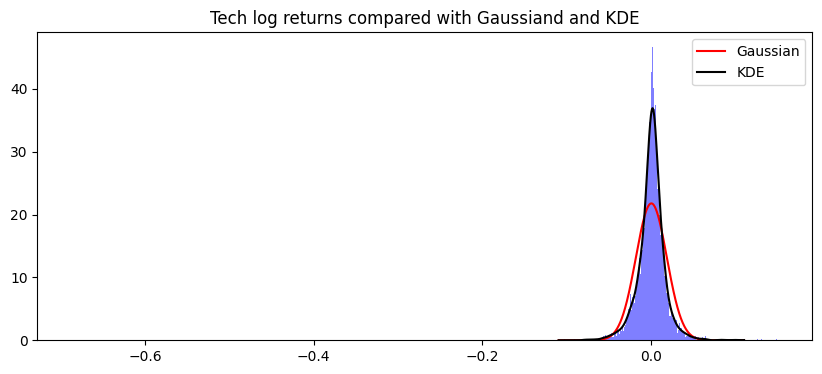

skew: -3.146422821507442, kurtosis: 105.41290203110577


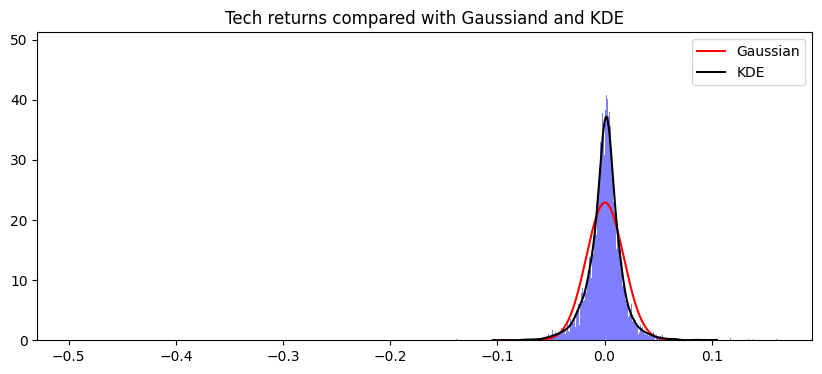

In [3]:
from scipy.stats import gaussian_kde, skew, kurtosis

def plot_with_noise(series:pd.Series, title:str):
    plt.figure(figsize=(10,4))
    plt.hist(series, bins=1000,
            color='blue', density=True, alpha=0.5)
    mu = series.mean()
    sigma = series.std()
    x = np.linspace(mu-6*sigma, mu+6*sigma, 1000)
    plt.plot(x, norm.pdf(x, mu, sigma),
            color='red', label="Gaussian"
            )
    
    kde = gaussian_kde(series.dropna())
    plt.plot(x, kde(x),
            color='black', label="KDE"
            )
    print(f"skew: {skew(series)}, kurtosis: {kurtosis(series, fisher=False)}")
    plt.title(title)
    plt.legend()
    plt.show()

    

plot_with_noise(tech_sector_df["log_returns"], f"Tech log returns compared with Gaussiand and KDE")
plot_with_noise(tech_sector_df["returns"], f"Tech returns compared with Gaussiand and KDE")



From the plots above, we could see that using KDE which estimates the distribution of the returns without assuming that it is Gaussian leads to a much more accurate estimation of the returns. However, the kurtosis is still not accurately captured. This estimation could be further enhanced using a regime switching model.

- The KDE pdf is slightly skewed compared to the normal
- Peak of KDE is much higher, more clustered towards the mean
- Difference in tails

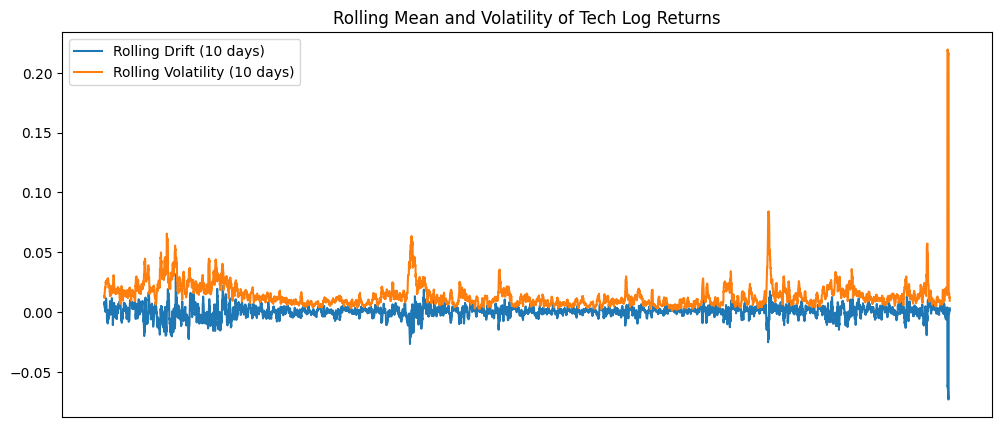

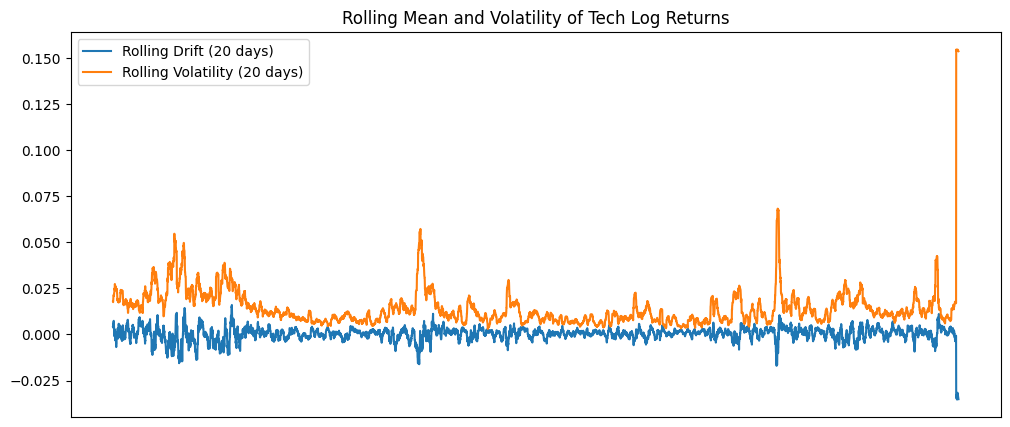

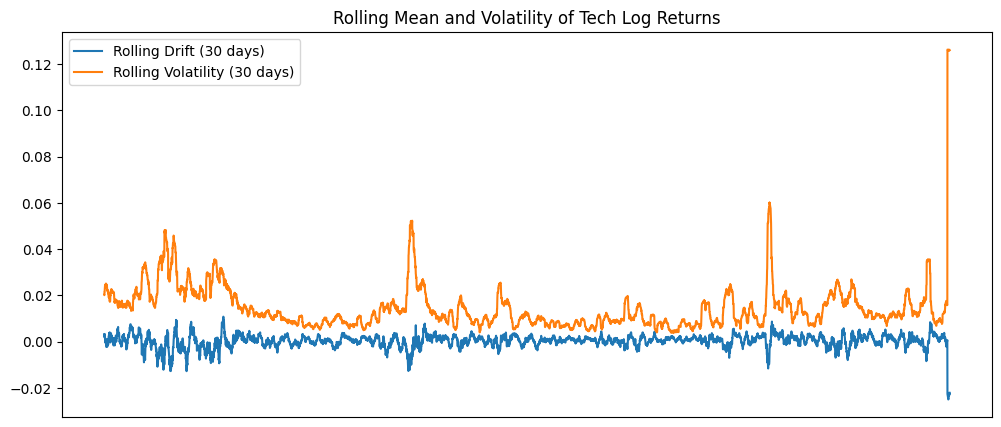

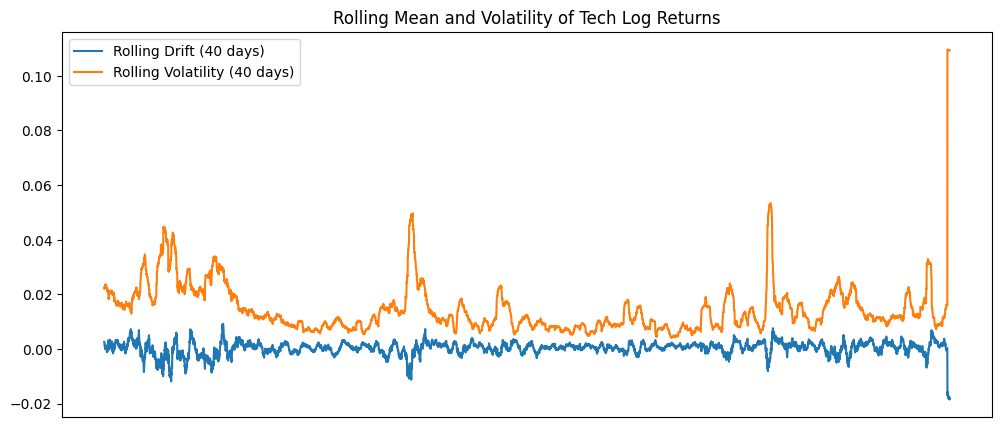

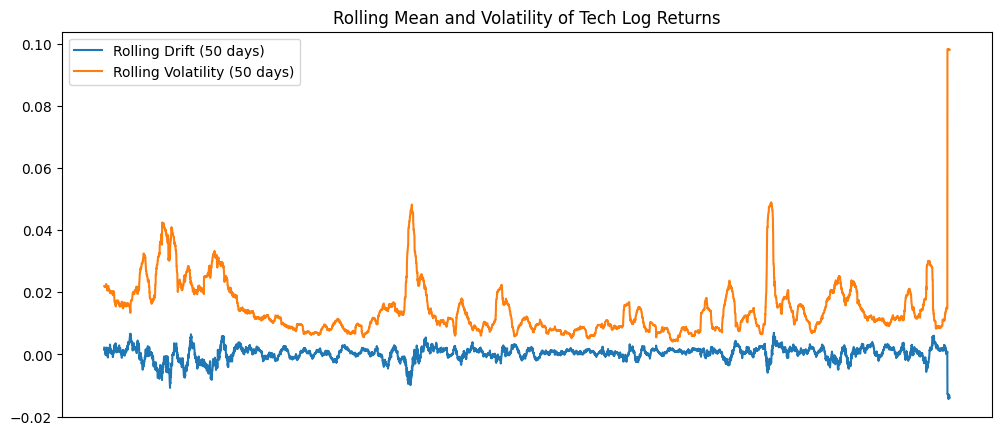

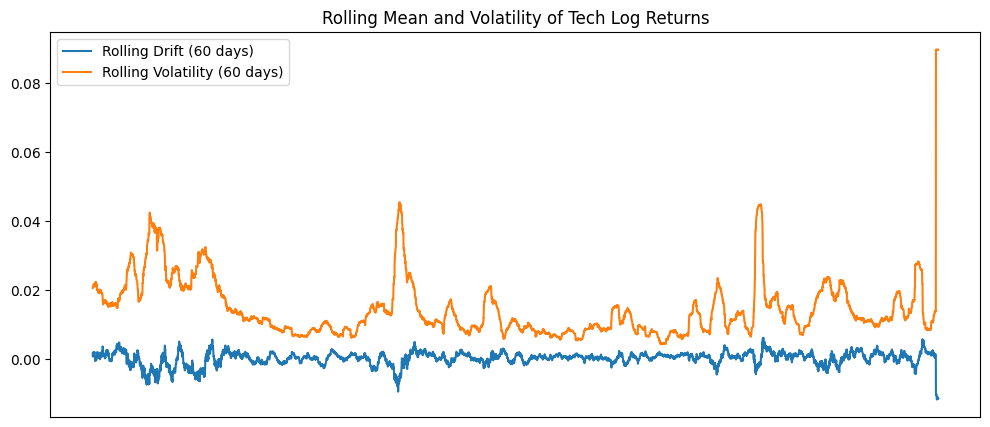

In [4]:
def plot_rolling_stats(time_series: pd.Series, window_size: int):
    rolling_means = time_series.rolling(window=window_size).mean().dropna()
    rolling_vols = time_series.rolling(window=window_size).std().dropna()

    plt.figure(figsize=(12, 5))
    plt.plot(rolling_means, label=f"Rolling Drift ({window_size} days)")
    plt.plot(rolling_vols, label=f"Rolling Volatility ({window_size} days)")
    plt.title("Rolling Mean and Volatility of Tech Log Returns")
    plt.xticks([])
    plt.legend()
    plt.show()

for window in range(10, 70, 10):
    plot_rolling_stats(tech_sector_df["log_returns"], window)

With the plots above, it is very easy to see that there are periods of volatility and drift clustering, which hints that the XLK index moves in regimes. 

Next, we will run KDE on rolling windows to check if different time windows follow different distributions.

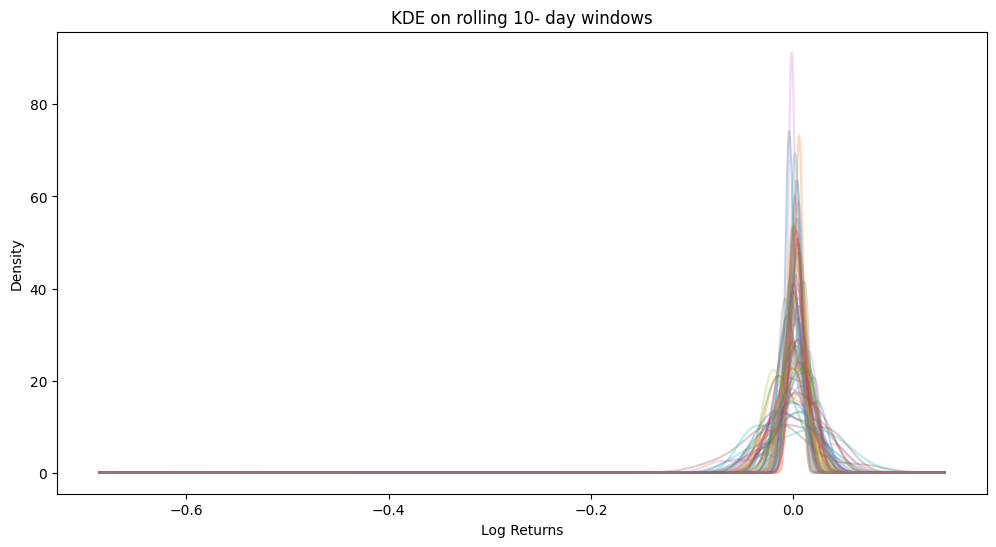

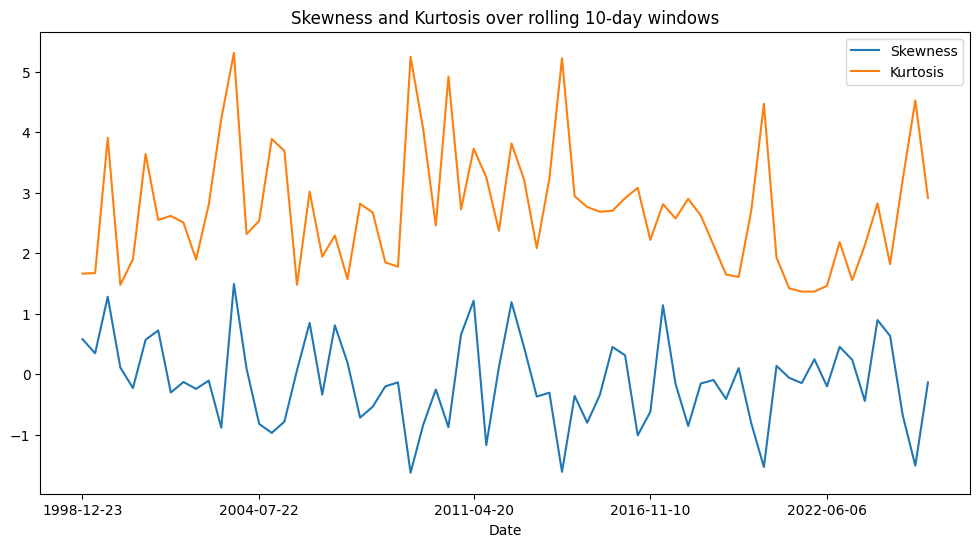

Average Skewness: -0.12493210691804035, Average Kurtosis: 2.730279949406527


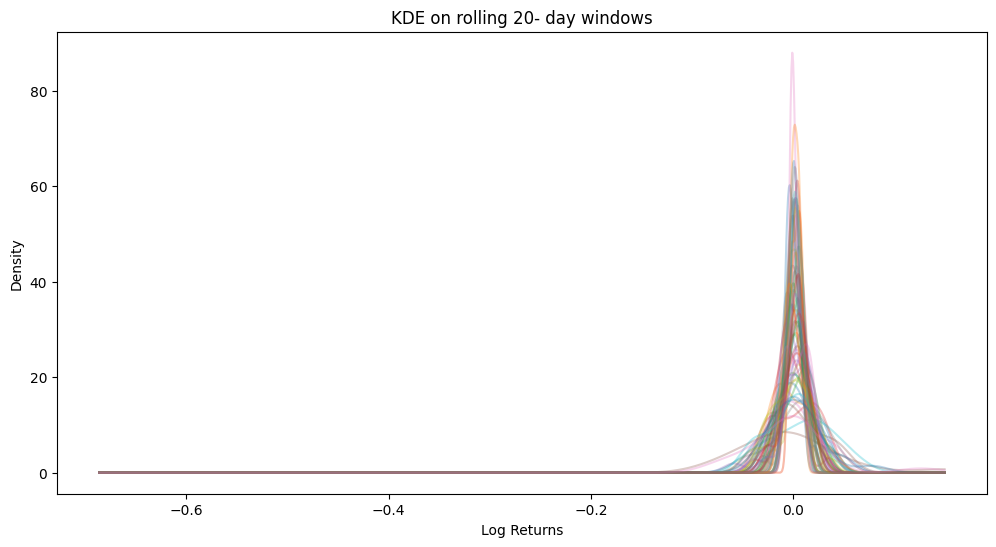

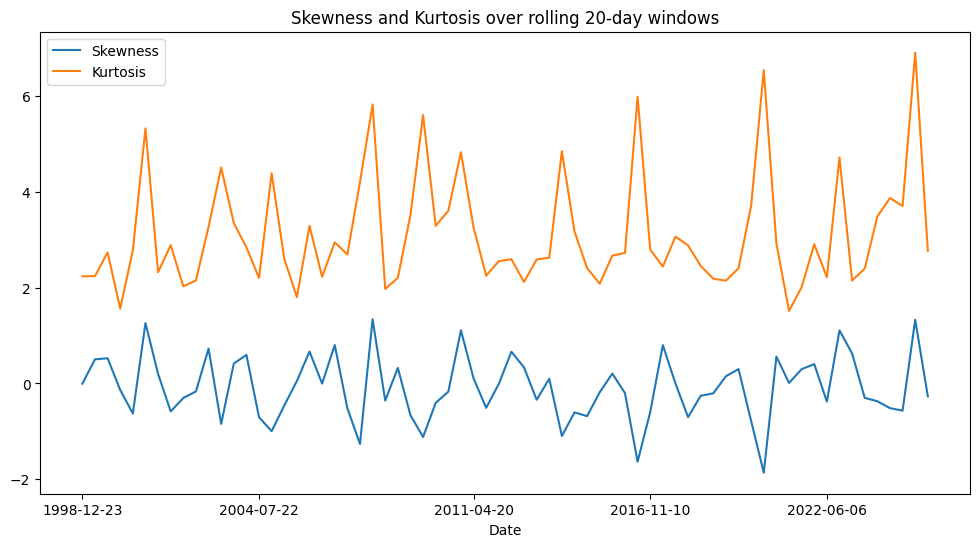

Average Skewness: -0.08662455586909948, Average Kurtosis: 3.1091519722783247


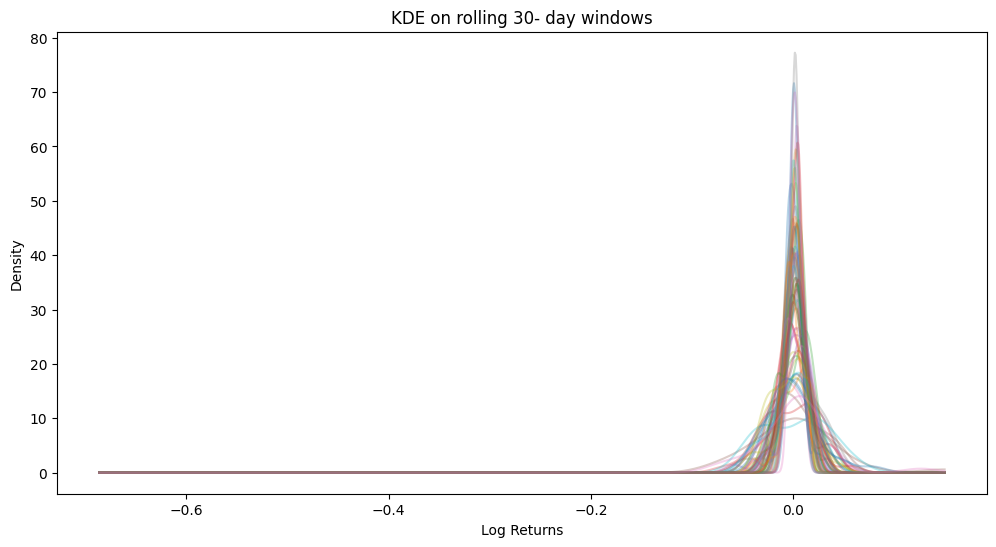

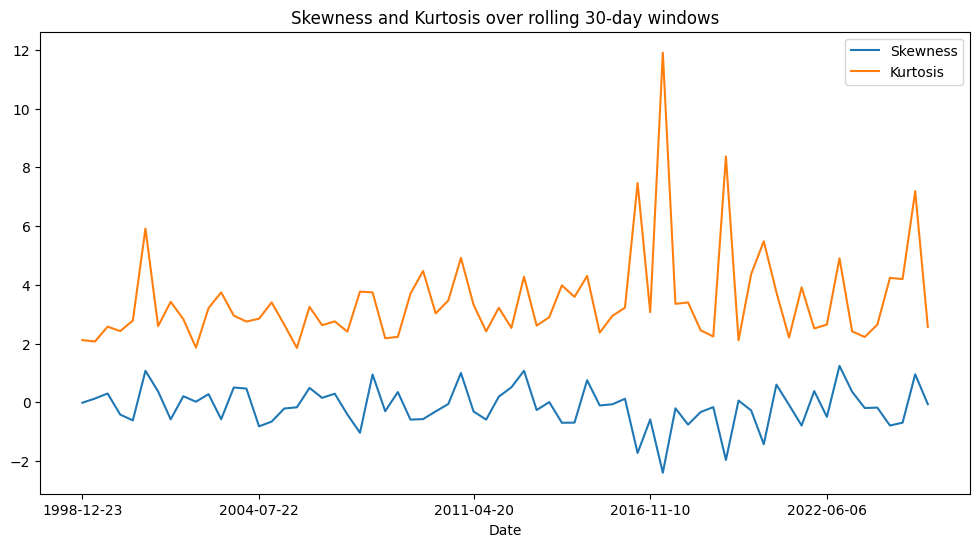

Average Skewness: -0.15052276480036525, Average Kurtosis: 3.4697256912718575


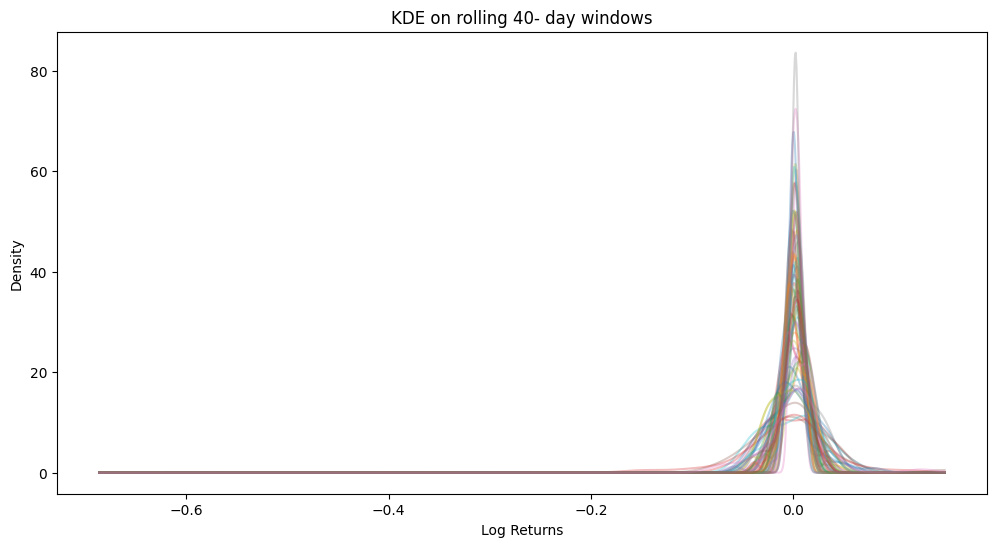

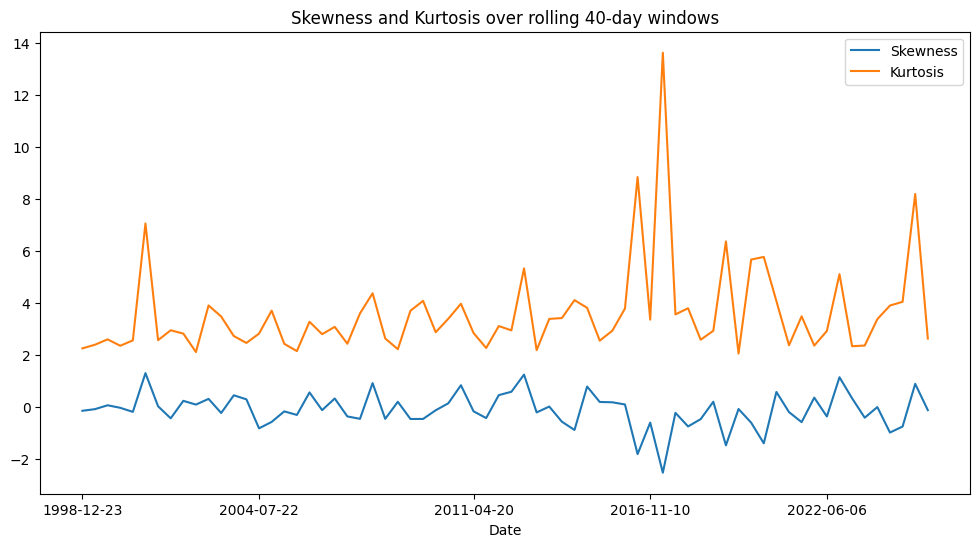

Average Skewness: -0.11800135310063847, Average Kurtosis: 3.5943884014077727


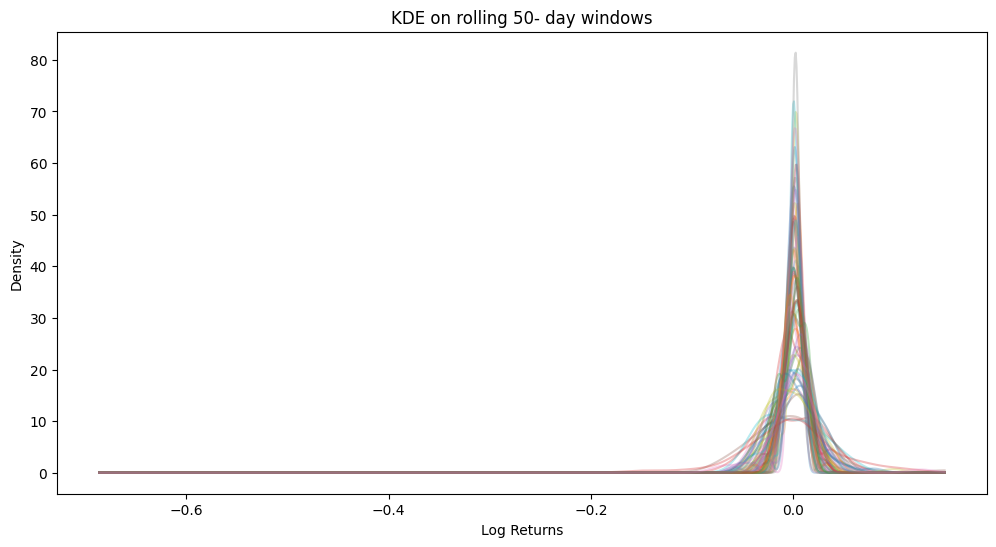

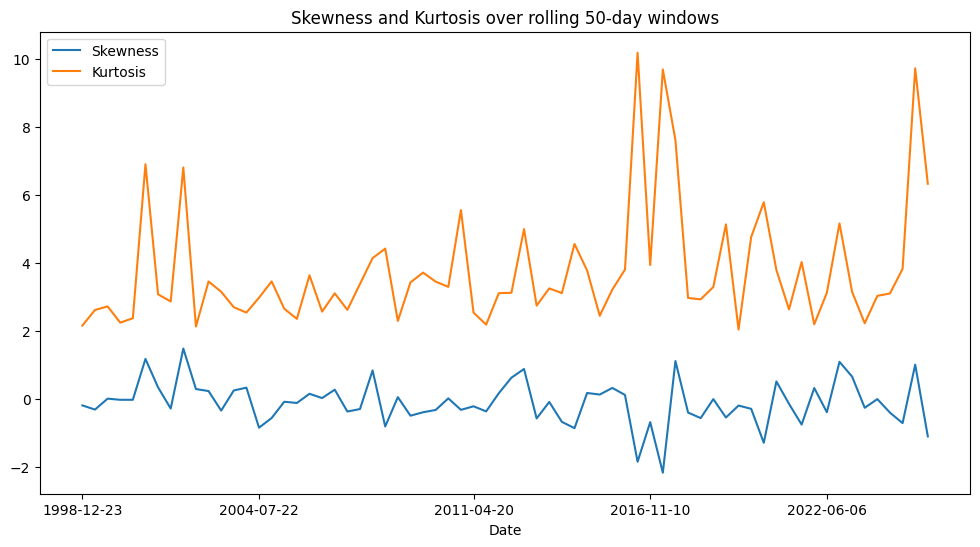

Average Skewness: -0.1034879109748531, Average Kurtosis: 3.774561836128795


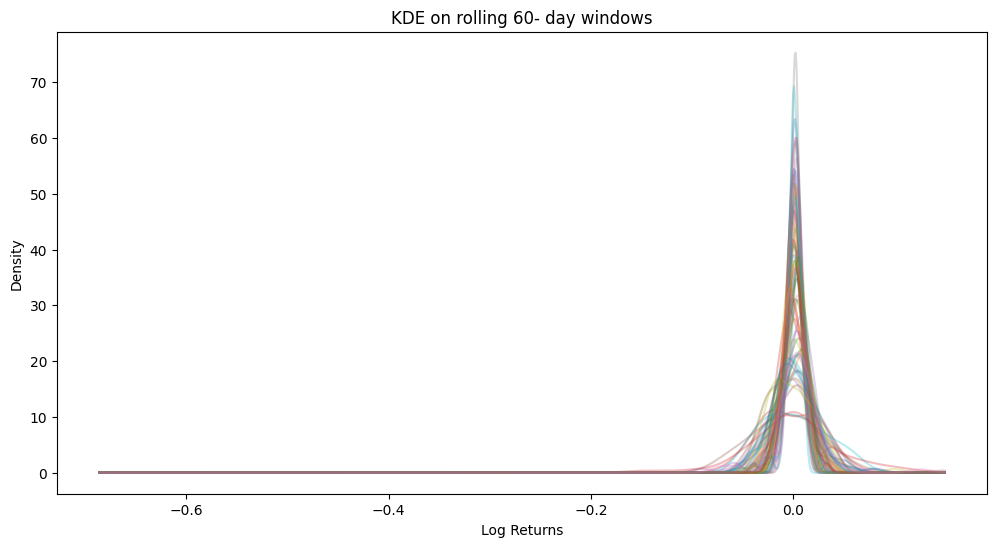

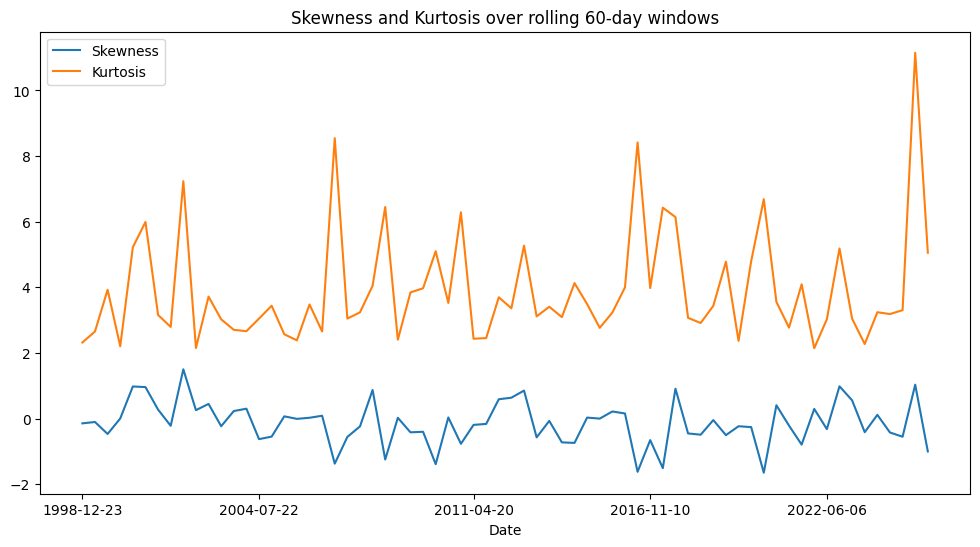

Average Skewness: -0.13696163375283646, Average Kurtosis: 3.932318225996366


In [5]:
import matplotlib.dates as mdates

def rolling_kde(time_series: pd.Series, window_size: int):
    n = len(time_series)
    x_min = time_series.min()
    x_max = time_series.max()
    x_grid = np.linspace(x_min, x_max, 1000)

    skews = []
    kurtoses = []

    plt.figure(figsize=(12, 6))
    plt.title(f"KDE on rolling {window_size}- day windows")

    # step is used since I don't want to plot each window
    for start in range(0, n - window_size + 1, step:=100):
        window_data = time_series[start:start + window_size].dropna()
        if len(window_data) < window_size:
            continue

        kde = gaussian_kde(window_data)
        plt.plot(x_grid, kde(x_grid), alpha=0.3)

        skews.append(skew(window_data))
        kurtoses.append(kurtosis(window_data, fisher=False))
    
    plt.xlabel("Log Returns")
    plt.ylabel("Density")
    plt.show()

    x = range(0, n - window_size + 1, step)
    dates = tech_sector_df["date"].iloc[list(x)]
    dates = dates.apply(lambda d: d.split("T")[0])
    plt.figure(figsize=(12, 6))
    plt.plot(dates, skews, label="Skewness")
    plt.plot(dates, kurtoses, label="Kurtosis")
    plt.title(f"Skewness and Kurtosis over rolling {window_size}-day windows")
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=8, maxticks=10))
    plt.legend()
    plt.xlabel("Date")
    plt.show()
    print(f"Average Skewness: {np.mean(skews)}, Average Kurtosis: {np.mean(kurtoses)}")

for window in range(10, 61, 10):
    rolling_kde(tech_sector_df["log_returns"], window)
    
    

With these results, we could clearly see that different time windows follow very different
distributions, showing that this index does in fact move in regimes, which are latent and could
not be simply modeled using some thresholds.

Now using some of the data from the DataPipeline class, I will check how the correlation changes during 60 day rolling windows

Response df for NVDA: 
                                      open      high      low   close  \
symbol timestamp                                                       
NVDA   2016-01-04 05:00:00+00:00   32.290   32.5800   32.040   32.37   
       2016-01-05 05:00:00+00:00   32.980   33.4400   32.500   32.89   
       2016-01-06 05:00:00+00:00   32.350   32.5000   31.160   31.53   
       2016-01-07 05:00:00+00:00   30.740   30.9530   29.880   30.28   
       2016-01-08 05:00:00+00:00   30.670   30.7000   29.565   29.63   
...                                   ...       ...      ...     ...   
       2025-12-26 05:00:00+00:00  189.920  192.6900  188.000  190.53   
       2025-12-29 05:00:00+00:00  187.710  188.7550  185.910  188.22   
       2025-12-30 05:00:00+00:00  188.240  188.9900  186.930  187.54   
       2025-12-31 05:00:00+00:00  189.570  190.5600  186.490  186.50   
       2026-01-02 05:00:00+00:00  189.835  192.9299  188.260  188.85   

                                       

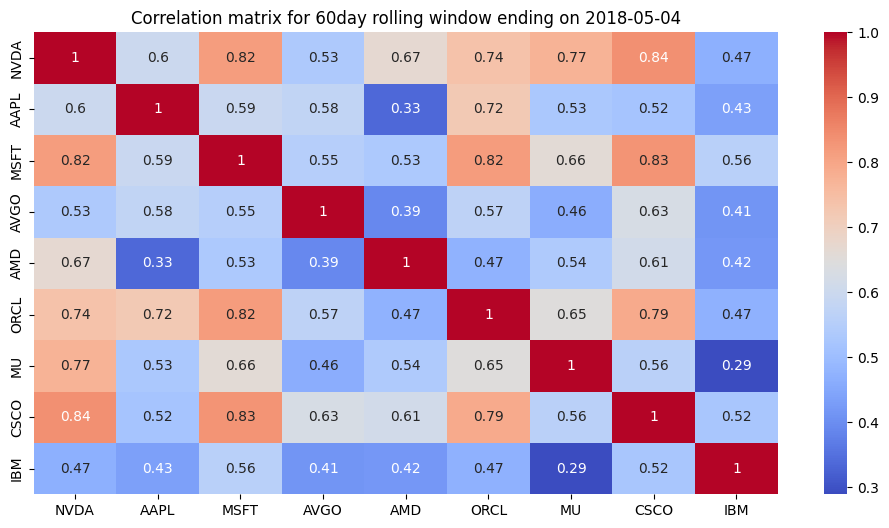

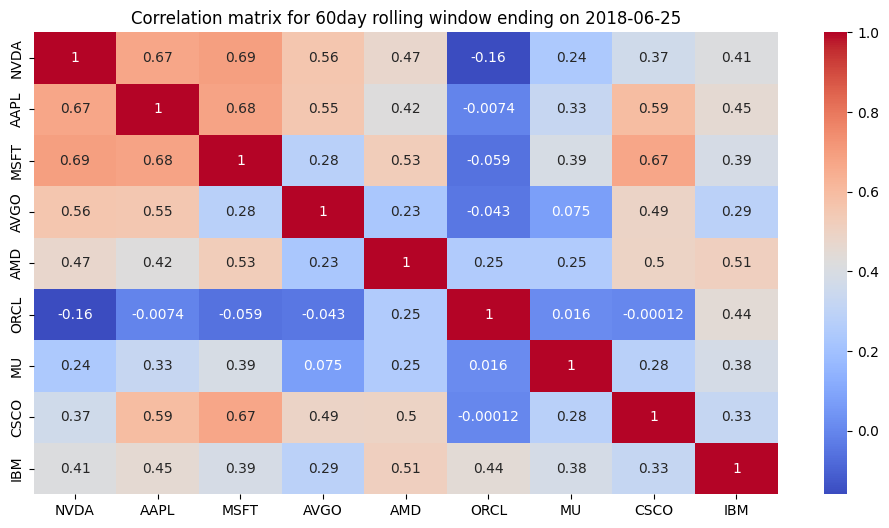

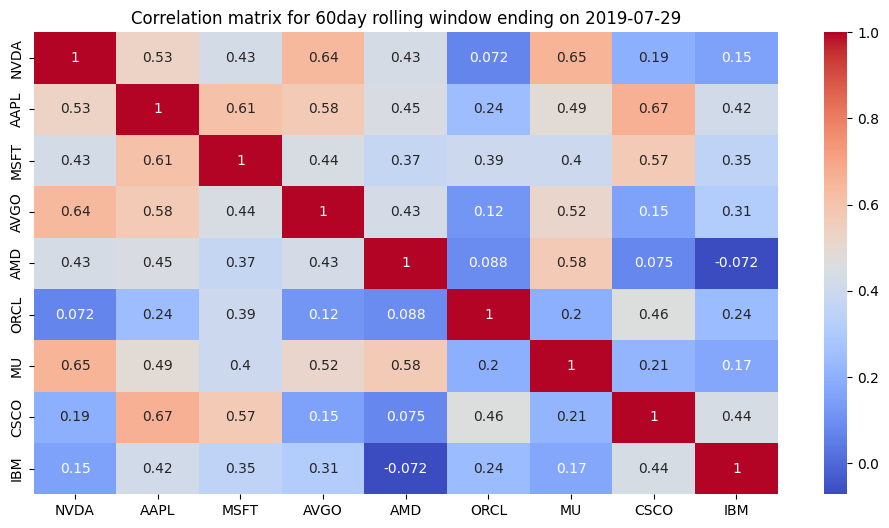

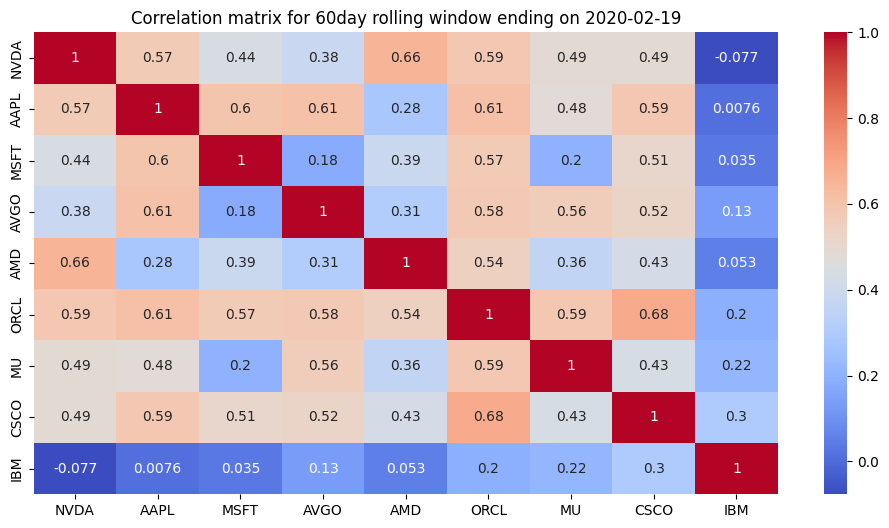

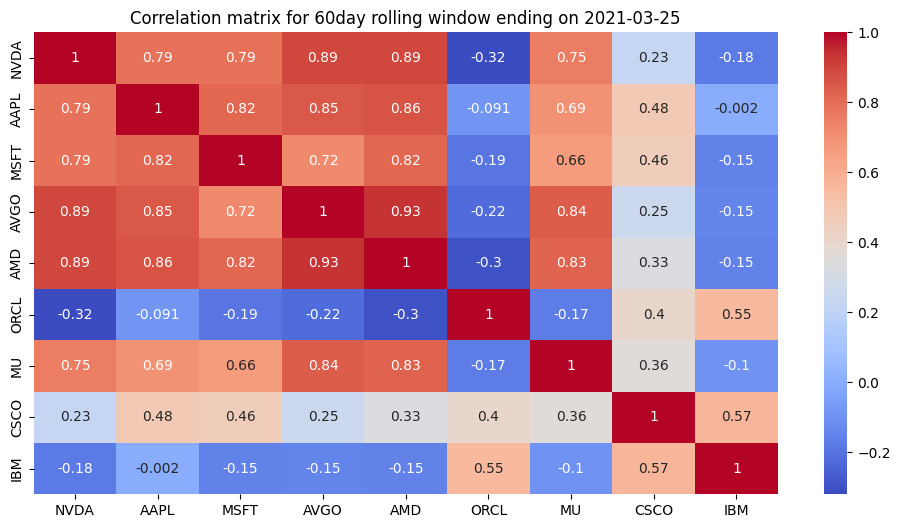

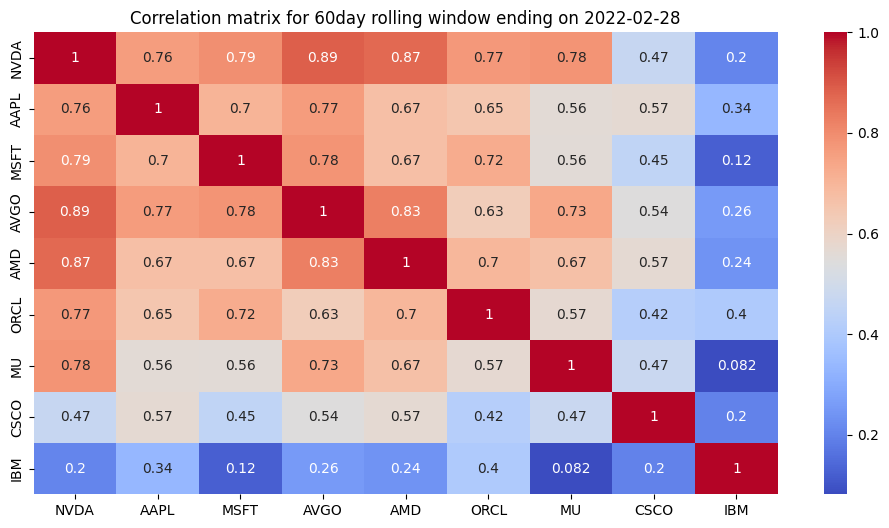

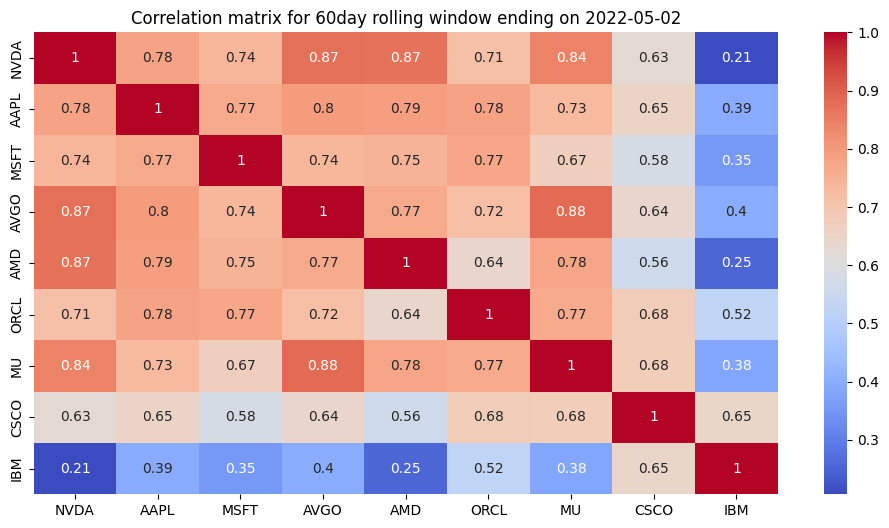

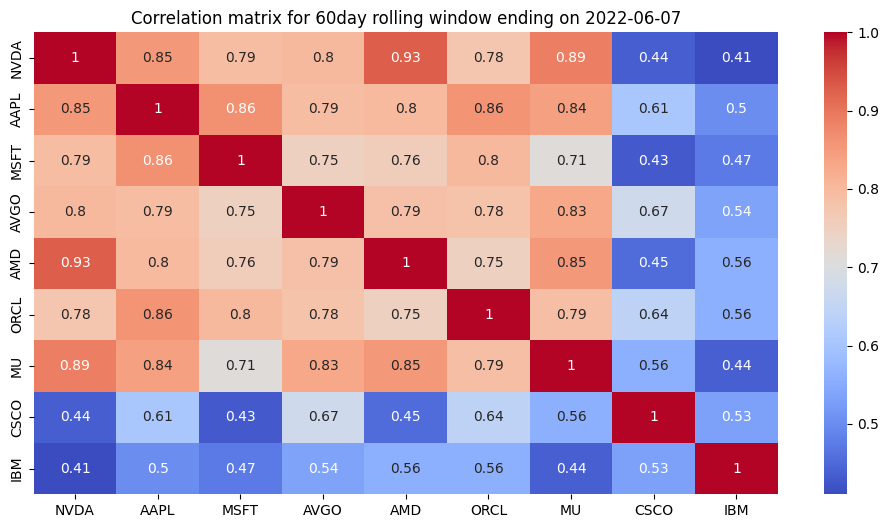

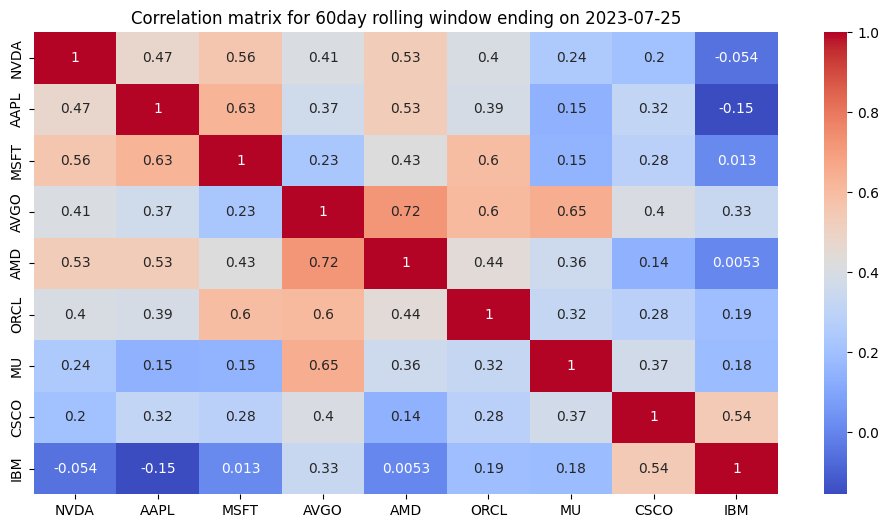

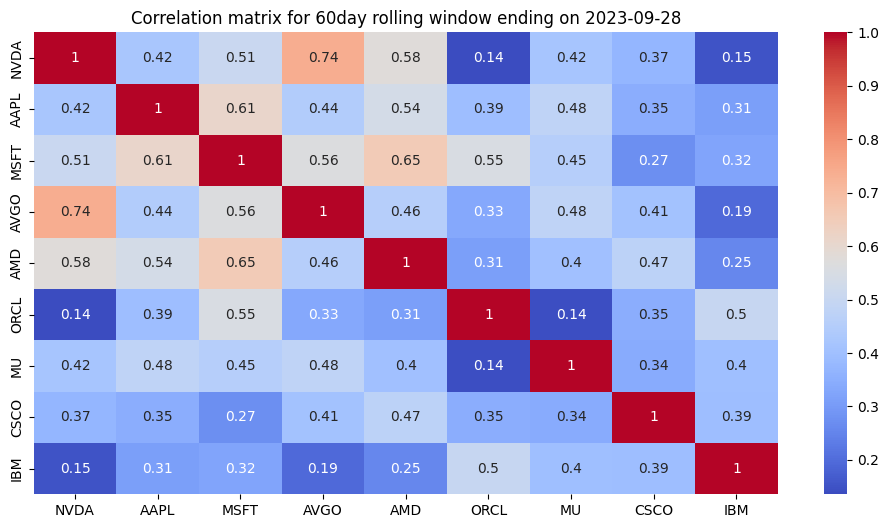

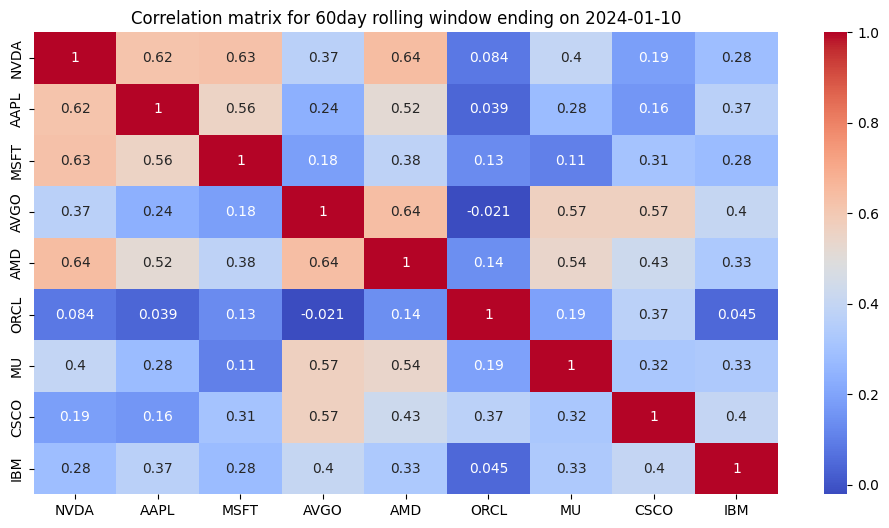

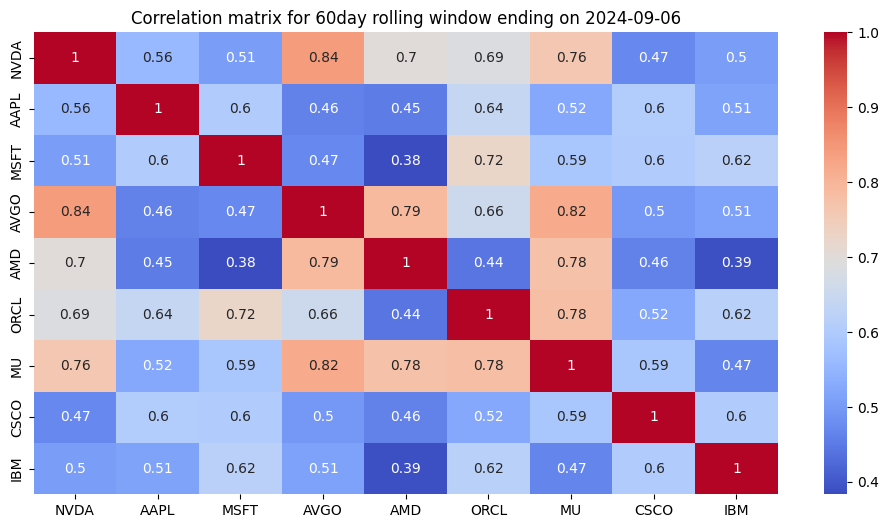

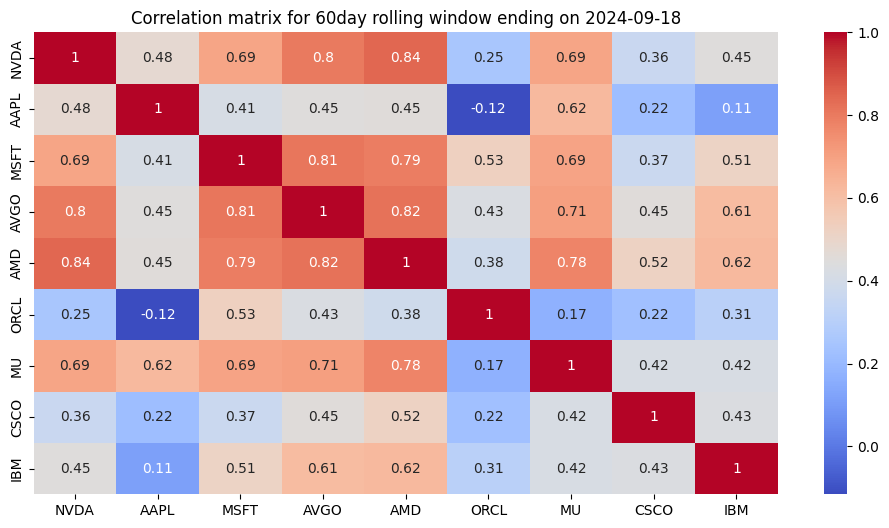

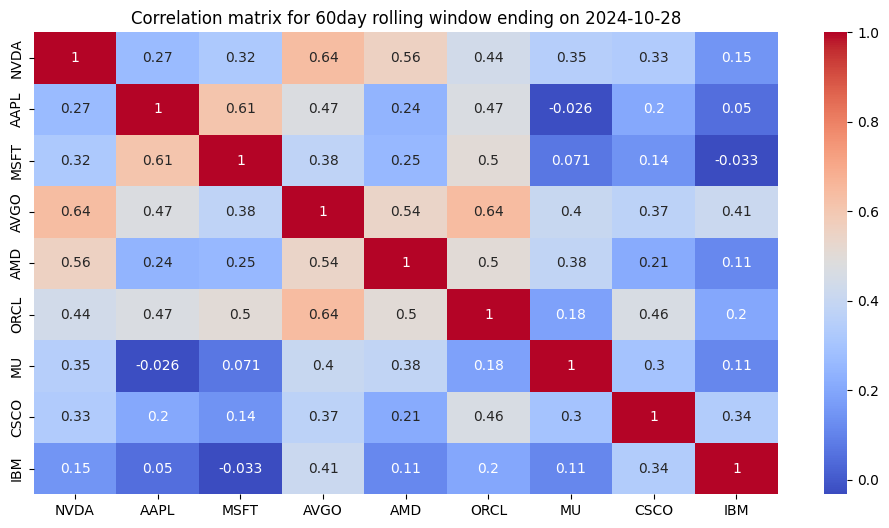

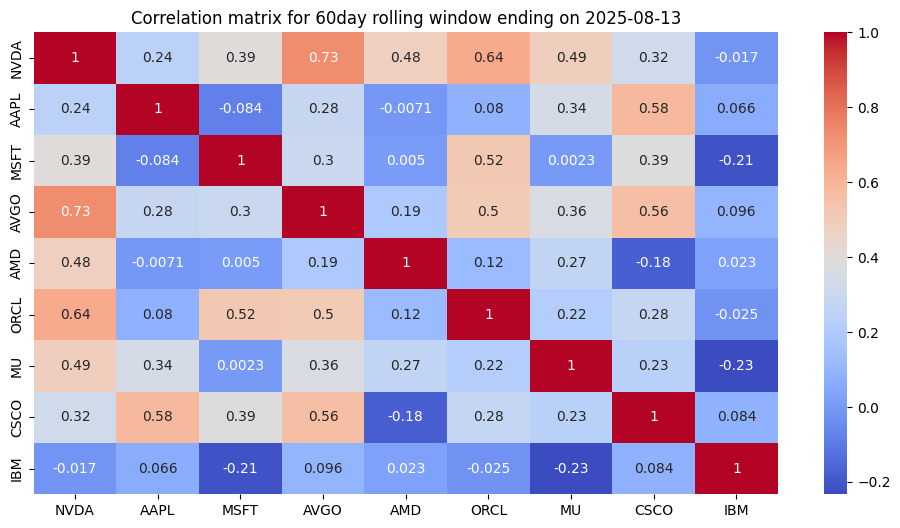

In [6]:
import random  
sys.path.append("..")

from dataPipeline.fetchData import DataPipeLine  

dp = DataPipeLine()

correlation_matrices_with_end_date = dp.get_full_corr_matrices_of_holdings()
holdings = DataPipeLine.TOP_HOLDINGS_XLK
n = len(correlation_matrices_with_end_date)
print(f"There are {n} different correlation matrices")
# Will plot 15 random different correlation matrices to see how they differ

indices_to_use = sorted(random.sample(range(n), 15))

for i in indices_to_use:
    end_date, corr_matrix = correlation_matrices_with_end_date[i]

    plt.figure(figsize=(12, 6))
    plt.title(f"Correlation matrix for 60day rolling window ending on {end_date}")
    sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, xticklabels=holdings, yticklabels=holdings)
    plt.show()
    



From the results seen above, we could see that the correlations of the major 
holdings of this index do seem to be moving differently over different
rolling windows. We could also see that the vol moves very differently in 
different periods. Additionally using KDE, we could observe that distributions
do seem to cluster over different windows of time